<a href="https://colab.research.google.com/github/Requiessss/DATA-science-prj/blob/main/Main_prj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

arms_df = pd.read_csv("arms_transfers_final_clean.csv")

arms_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9741 entries, 0 to 9740
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9741 non-null   object 
 1   Supplier                        9741 non-null   object 
 2   Year of order                   9741 non-null   int64  
 3   Number ordered                  9656 non-null   float64
 4   Weapon designation              9741 non-null   object 
 5   Weapon description              9741 non-null   object 
 6   Deliveries in the Year Range    9741 non-null   float64
 7   Year(s) of delivery             9741 non-null   object 
 8   status                          9741 non-null   object 
 9   SIPRI TIV per unit              9741 non-null   float64
 10  SIPRI TIV for total order       9741 non-null   float64
 11  SIPRI TIV of delivered weapons  9741 non-null   float64
 12  Number ordered missing          97

In [3]:
arms_df.to_csv("arms_transfers_final_clean.csv", index=False)

In [ ]:
arms_df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,85
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,0
Year(s) of delivery,0
status,0
SIPRI TIV per unit,0


In [4]:
arms_df.to_csv("us_arms_transfers_cleaned.csv", index=False)

In [ ]:
#How many transfer occured each year
arms_df.groupby("Year of order").size().sort_index()

,0
Year of order,
1940,1
1945,1
1946,3
1947,4
1948,16
...,...
2021,113
2022,176
2023,155


In [ ]:
#Which countires recieved the most US arms transfers
top_recipients = (
    arms_df.groupby("Recipient")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_recipients

,0
Recipient,
South Korea,381
Japan,361
Taiwan,356
United States,307
Israel,303
Turkiye,294
Greece,285
Thailand,277
Saudi Arabia,254


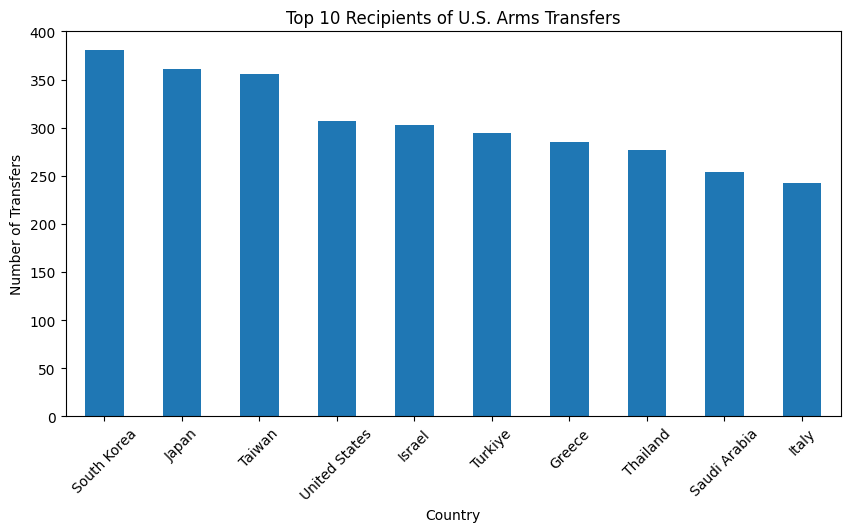

In [ ]:
#Which countires recieved the most US arms transfers
import matplotlib.pyplot as plt

top_recipients.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Recipients of U.S. Arms Transfers")
plt.xlabel("Country")
plt.ylabel("Number of Transfers")
plt.xticks(rotation=45)

plt.show()

In [ ]:
#which wepons cat is exported the most
arms_df['Weapon description'].value_counts().head(10)

,count
Weapon description,
armoured personnel carrier,553
transport aircraft,540
helicopter,433
light transport aircraft,422
fighter/ground-attack aircraft,416
light helicopter,385
surface-to-air missile,314
long-range air-to-air missile,285
light aircraft,283


In [ ]:
#which countries receive the greatest total military value
#add note: Think of it as measuring the size and quality of the toolbox, not how skilled the carpenter is.
arms_df.groupby("Recipient")["SIPRI TIV for total order"] \
.sum() \
.sort_values(ascending=False) \
.head(20)

,SIPRI TIV for total order
Recipient,
Japan,78457.94
Saudi Arabia,59005.28
United States,54622.98
Germany,50286.28
South Korea,49200.08
Israel,43671.13
Taiwan,40969.57
United Kingdom,39647.18
Turkiye,36038.63


In [ ]:
#Which weapon systems have the highest total valu
arms_df.groupby("Weapon designation")["SIPRI TIV for total order"] \
.sum() \
.sort_values(ascending=False) \
.head(10)

,SIPRI TIV for total order
Weapon designation,
F-35A Lightning-2,51425.00
F-16C,21740.94
F-104G Starfighter,20793.92
F-16C Block-50,19282.00
F-4E Phantom-2,18450.00
F-16A,17274.96
F-15 Advanced Eagle,16467.00
F-15C Eagle,15732.00
C-130H Hercules,15282.96


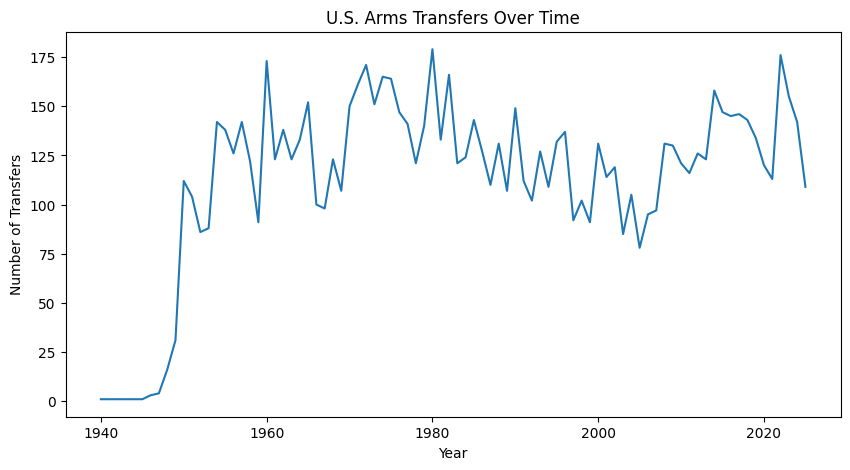

In [ ]:
#How has U.S. arms transfer activity changed over time
orders_by_year = (
    arms_df.groupby("Year of order")
    .size()
)

orders_by_year.plot(figsize=(10,5))

plt.title("U.S. Arms Transfers Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Transfers")

plt.show()

In [ ]:
long_term_recipients = (
    arms_df.groupby("Recipient")["Year of order"]
    .agg(["min", "max", "count", "nunique"])
    .sort_values("nunique", ascending=False)
)

long_term_recipients.head(15)

,min,max,count,nunique
Recipient,,,,
South Korea,1949,2024,381,74
Taiwan,1951,2025,356,73
Thailand,1946,2025,277,73
Japan,1951,2025,361,72
Italy,1948,2025,242,70
Greece,1949,2024,285,70
Turkiye,1949,2024,294,70
United States,1947,2025,307,69
Australia,1950,2025,211,67


In [ ]:
arms_df["status"].value_counts()

,count
status,
New,6997
Second hand,2594
Second hand but modernized,150


In [ ]:
import os
os.listdir()

['.config', 'arms_transfers_final_clean.csv', 'sample_data']

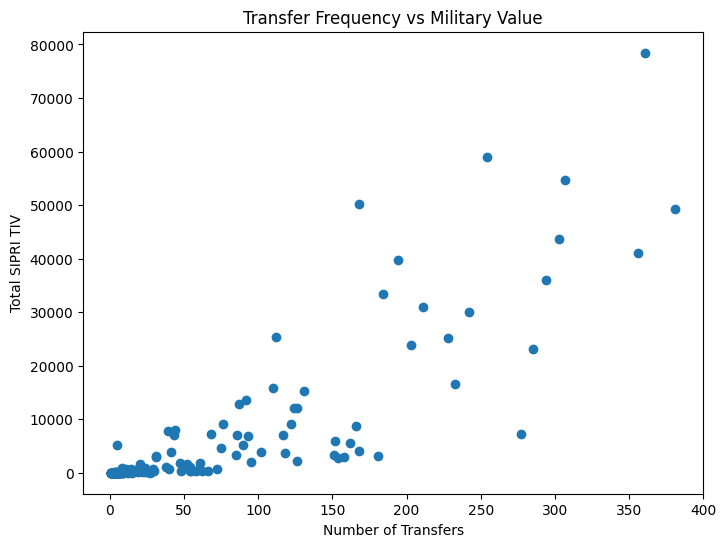

In [ ]:
country_summary = (
    arms_df.groupby("Recipient")
    .agg({
        "SIPRI TIV for total order":"sum",
        "Recipient":"count"
    })
)

country_summary.columns=["Total_TIV","Transfers"]

plt.figure(figsize=(8,6))

plt.scatter(
    country_summary["Transfers"],
    country_summary["Total_TIV"]
)

plt.xlabel("Number of Transfers")
plt.ylabel("Total SIPRI TIV")
plt.title("Transfer Frequency vs Military Value")

plt.show()

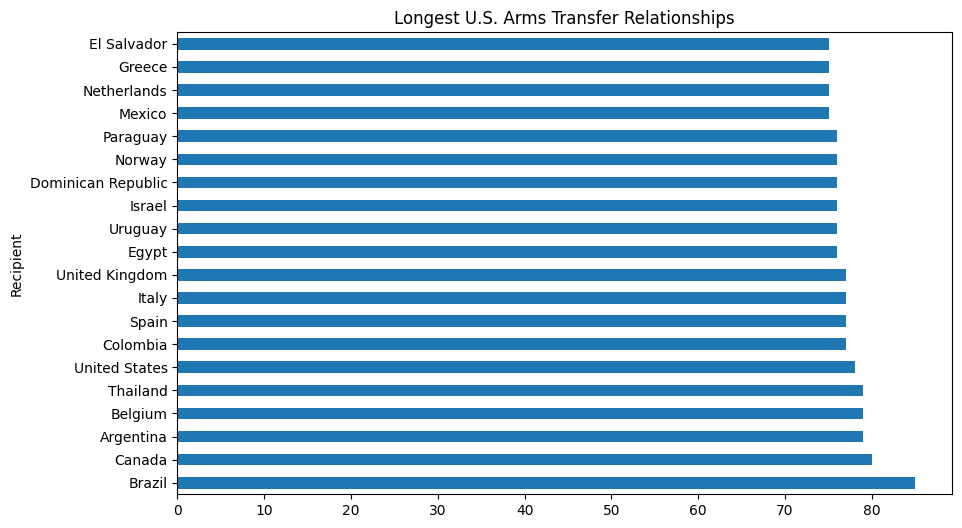

In [ ]:
relationship = (
    arms_df.groupby("Recipient")["Year of order"]
    .agg(["min","max"])
)

relationship["Years"] = relationship["max"] - relationship["min"]

relationship["Years"]\
.sort_values(ascending=False)\
.head(20)\
.plot(kind="barh", figsize=(10,6))

plt.title("Longest U.S. Arms Transfer Relationships")

plt.show()

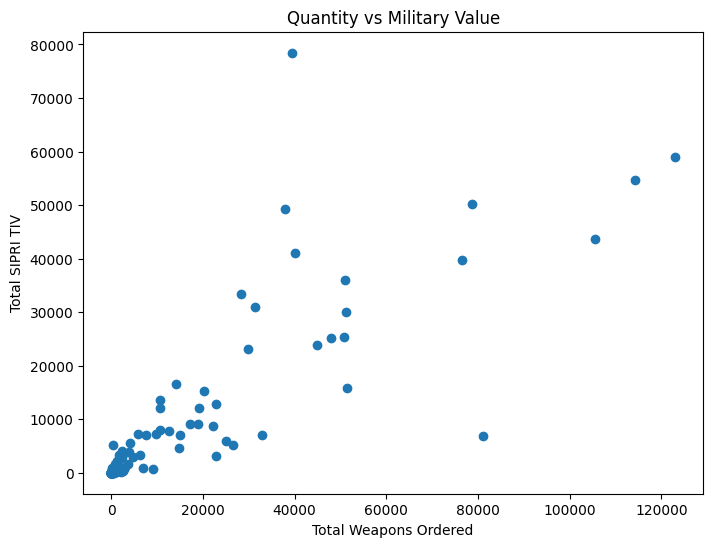

In [ ]:
#fixed point value (TIV) based on how big, powerful, and advanced it is
country_summary = (
    arms_df.groupby("Recipient")
    .agg({
        "Number ordered":"sum",
        "SIPRI TIV for total order":"sum"
    })
)

plt.figure(figsize=(8,6))

plt.scatter(
    country_summary["Number ordered"],
    country_summary["SIPRI TIV for total order"]
)

plt.xlabel("Total Weapons Ordered")
plt.ylabel("Total SIPRI TIV")
plt.title("Quantity vs Military Value")

plt.show()

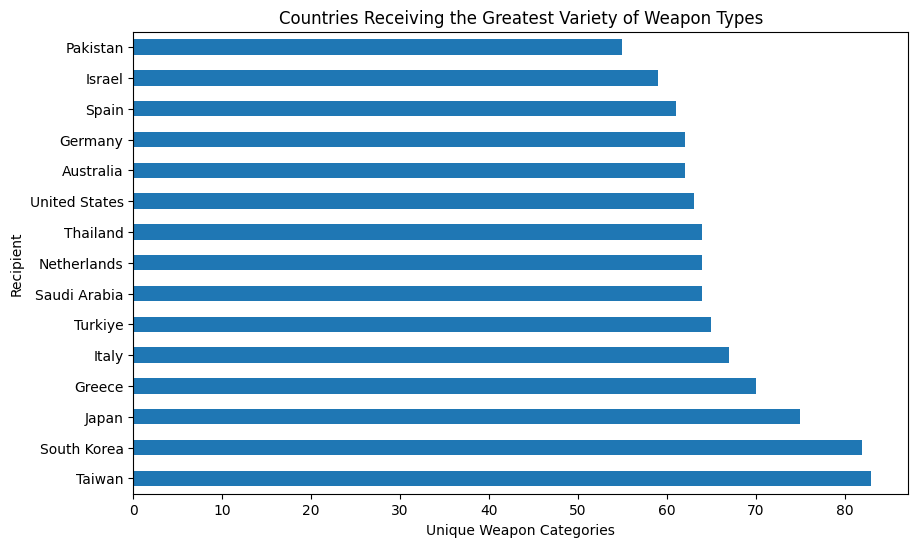

In [ ]:
weapon_diversity = (
    arms_df.groupby("Recipient")["Weapon description"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

weapon_diversity.plot(kind="barh", figsize=(10,6))

plt.title("Countries Receiving the Greatest Variety of Weapon Types")

plt.xlabel("Unique Weapon Categories")
plt.show()

In [ ]:
%who DataFrame

arms_df	 


In [ ]:
for col in arms_df.columns:
    print(col)

Recipient
Supplier
Year of order
Number ordered
Weapon designation
Weapon description
Deliveries in the Year Range
Year(s) of delivery
status
SIPRI TIV per unit
SIPRI TIV for total order
SIPRI TIV of delivered weapons
Number ordered missing


In [ ]:
import pandas as pd
import re

# Extract the first year from the "Year(s) of delivery" column
def first_delivery_year(x):
    if pd.isna(x):
        return None

    match = re.search(r"\d{4}", str(x))
    if match:
        return int(match.group())
    return None

arms_df["first_delivery_year"] = arms_df["Year(s) of delivery"].apply(first_delivery_year)

# Convert order year to numeric
arms_df["Year of order"] = pd.to_numeric(
    arms_df["Year of order"],
    errors="coerce"
)

# Calculate delivery delay
arms_df["delivery_delay"] = (
    arms_df["first_delivery_year"]
    - arms_df["Year of order"]
)

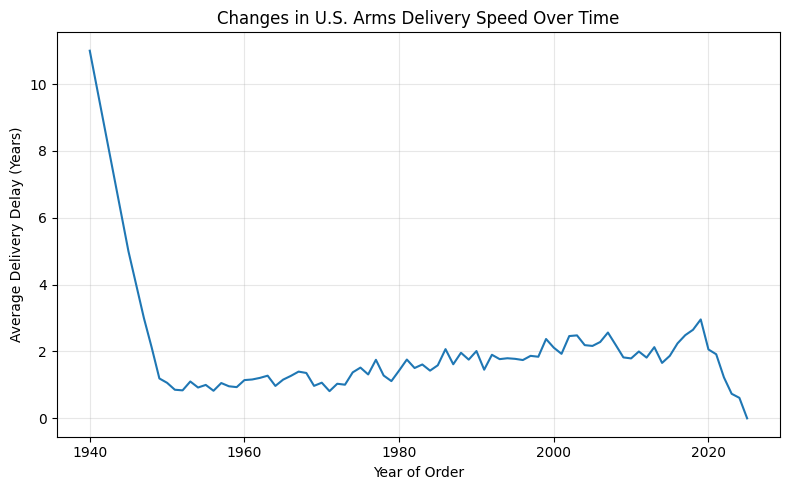

In [ ]:
import matplotlib.pyplot as plt

# Average delivery delay by order year
delay_by_year = (
    arms_df
    .groupby("Year of order")["delivery_delay"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(
    delay_by_year.index,
    delay_by_year.values
)

plt.xlabel("Year of Order")
plt.ylabel("Average Delivery Delay (Years)")
plt.title("Changes in U.S. Arms Delivery Speed Over Time")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## RESERCH QUESTION ???????????: Do U.S. arms recipient countries cluster into distinct combinations of delivery speed and equipment condition (1950–2025), and what do the resulting patterns — including cases with mismatched speed and condition — reveal about the nature of different security relationships?

In [22]:
#importing libearises
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
#looking at missing values again
arms_df.isnull().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,85
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,0
Year(s) of delivery,0
status,0
SIPRI TIV per unit,0


In [8]:
# Extract the first delivery year
arms_df["first_delivery_year"] = (
    arms_df["Year(s) of delivery"]
    .str.extract(r'(\d{4})')[0]
)

# Converting to numeric
arms_df["first_delivery_year"] = pd.to_numeric(
    arms_df["first_delivery_year"],
    errors="coerce"
)

In [9]:
#calcute delivery delay
arms_df["delivery_delay"] = (
    arms_df["first_delivery_year"]
    - arms_df["Year of order"]
)

In [10]:
#verifying new varibles
arms_df[[
    "Year of order",
    "Year(s) of delivery",
    "first_delivery_year",
    "delivery_delay"
]].head(10)

,Year of order,Year(s) of delivery,first_delivery_year,delivery_delay
0,2015,2015,2015.0,0.0
1,2004,2005,2005.0,1.0
2,2017,2018; 2019; 2020; 2021,2018.0,1.0
3,2006,2007; 2008,2007.0,1.0
4,2011,2011; 2012,2011.0,0.0
5,2010,2011; 2012; 2013,2011.0,1.0
6,2011,2012,2012.0,1.0
7,2011,2011; 2012,2011.0,0.0
8,2011,2011,2011.0,0.0
9,2008,2008; 2009; 2010; 2011,2008.0,0.0


In [11]:
#descriptive stats
arms_df["delivery_delay"].describe()

,delivery_delay
count,9319.000000
mean,1.584397
std,1.682370
min,0.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,18.000000


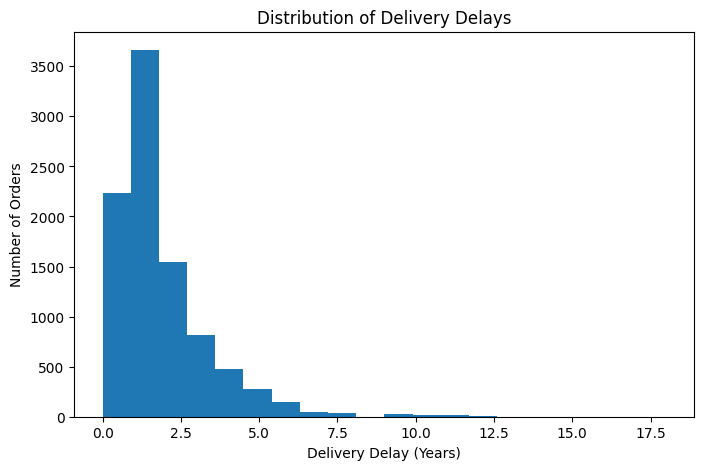

In [24]:
#distribution of deliervy delays
plt.figure(figsize=(8,5))

plt.hist(arms_df["delivery_delay"], bins=20)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Delivery Delay (Years)")
plt.ylabel("Number of Orders")

plt.show()

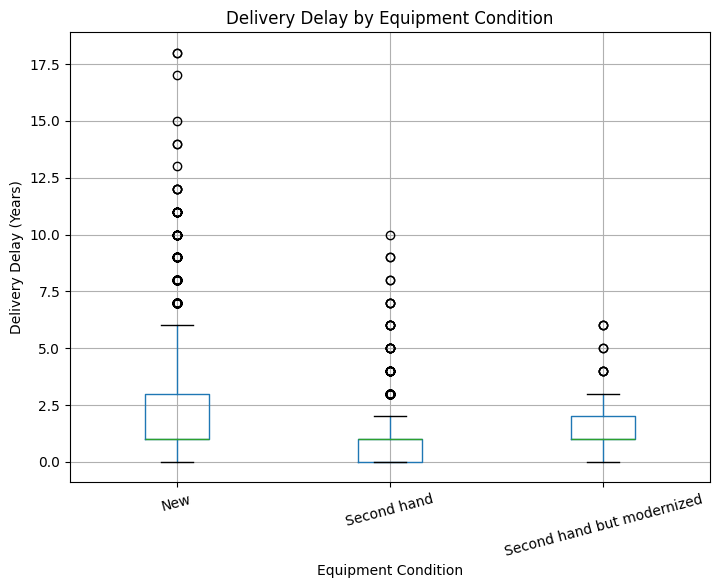

In [13]:
#deliervy delay by equipment condition
arms_df.boxplot(
    column="delivery_delay",
    by="status",
    figsize=(8,6)
)

plt.title("Delivery Delay by Equipment Condition")
plt.suptitle("")
plt.xlabel("Equipment Condition")
plt.ylabel("Delivery Delay (Years)")
plt.xticks(rotation=15)

plt.show()

In [14]:
#anova hypotheisi test
new = arms_df[
    arms_df["status"] == "New"
]["delivery_delay"].dropna()

second = arms_df[
    arms_df["status"] == "Second hand"
]["delivery_delay"].dropna()

modernized = arms_df[
    arms_df["status"] == "Second hand but modernized"
]["delivery_delay"].dropna()

f_stat, p_value = f_oneway(
    new,
    second,
    modernized
)

print("F-statistic:", round(f_stat,3))
print("P-value:", p_value)

F-statistic: 515.635
P-value: 4.0955349883458414e-213


In [15]:
#correlation analysis
arms_df[
    ["delivery_delay", "SIPRI TIV per unit"]
].corr()

,delivery_delay,SIPRI TIV per unit
delivery_delay,1.00000,0.15649
SIPRI TIV per unit,0.15649,1.00000


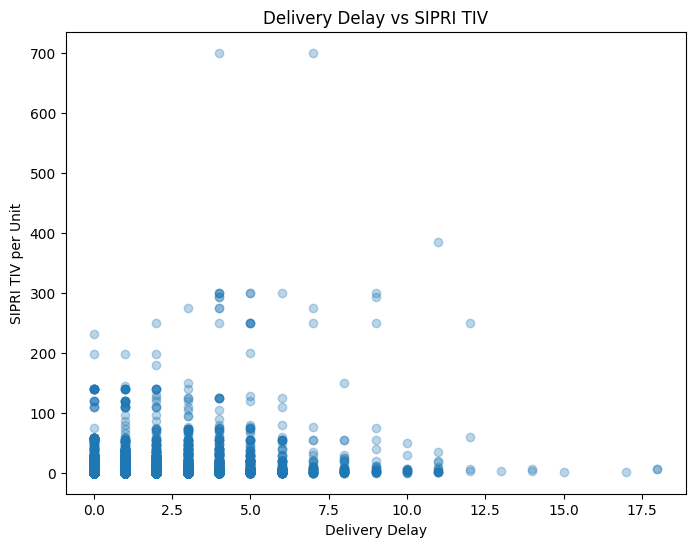

In [16]:
#scatter plot of the relationship between dleiervy delay and miltiary value
plt.figure(figsize=(8,6))

plt.scatter(
    arms_df["delivery_delay"],
    arms_df["SIPRI TIV per unit"],
    alpha=0.3
)

plt.xlabel("Delivery Delay")
plt.ylabel("SIPRI TIV per Unit")
plt.title("Delivery Delay vs SIPRI TIV")

plt.show()

In [17]:
#chi-square test
table = pd.crosstab(
    arms_df["status"],
    arms_df["Recipient"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", round(chi2,2))
print("P-value:", p)

Chi-square: 1670.37
P-value: 1.9257251969168432e-171


In [18]:
features = arms_df[
    [
        "delivery_delay",
        "SIPRI TIV per unit",
        "Number ordered"
    ]
].dropna()

In [19]:
scaler = StandardScaler()

scaled = scaler.fit_transform(features)

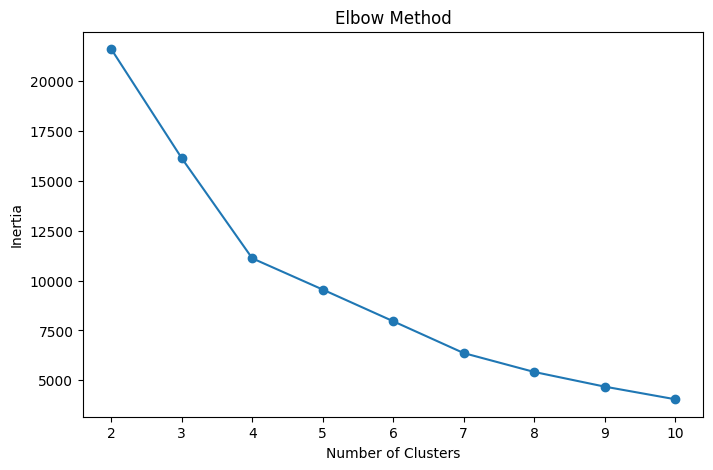

In [25]:
#elbow method
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

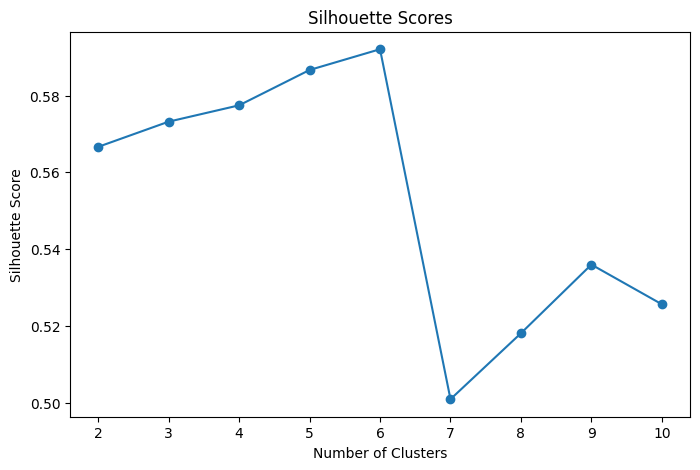

In [21]:
#silloutte anyalisis
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled)

    score = silhouette_score(
        scaled,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")

plt.show()

In [26]:
#k-mean model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(scaled)

In [27]:
cluster_summary = (
    features
    .groupby("Cluster")
    .agg({
        "delivery_delay": "mean",
        "SIPRI TIV per unit": "mean",
        "Number ordered": "mean"
    })
    .round(2)
)

cluster_summary

,delivery_delay,SIPRI TIV per unit,Number ordered
Cluster,,,
0,4.27,6.90,126.00
1,0.91,3.85,131.09
2,1.00,0.01,20571.54
3,1.89,79.81,7.47
4,5.34,301.43,3.34


In [28]:
features["Cluster"].value_counts().sort_index()

,count
Cluster,
0,1753
1,7240
2,13
3,247
4,29


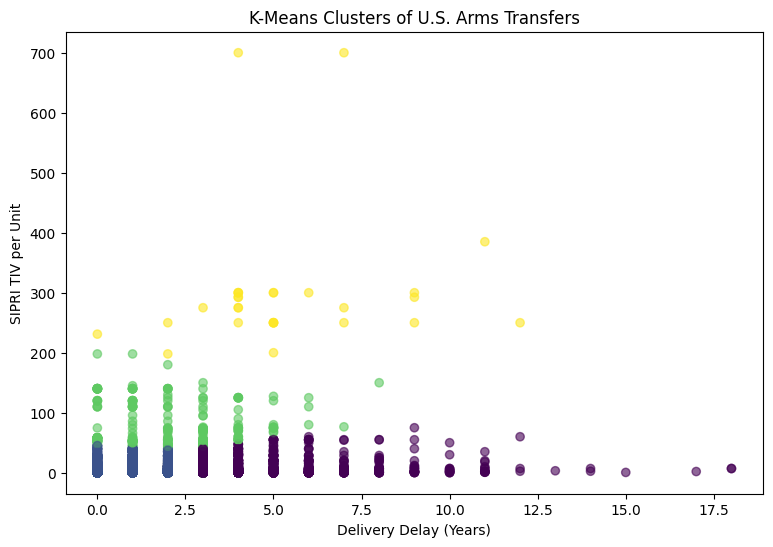

In [29]:
plt.figure(figsize=(9,6))

plt.scatter(
    features["delivery_delay"],
    features["SIPRI TIV per unit"],
    c=features["Cluster"],
    alpha=0.6
)

plt.xlabel("Delivery Delay (Years)")
plt.ylabel("SIPRI TIV per Unit")
plt.title("K-Means Clusters of U.S. Arms Transfers")

plt.show()